# Customer Shopping Behavior

## EncoderX Remote Internship — Data Science | Week 01

### Objective
The objective of this project is to explore customer shopping behavior,
clean and preprocess the dataset, identify important patterns and
relationships, create meaningful visualizations, and derive actionable
business insights.

Importing Libraries

In [35]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

Upload Excel file

In [36]:
from google.colab import files

uploaded = files.upload()

Saving shopping_trends.csv to shopping_trends (1).csv


Loading Dataset

In [37]:
df = pd.read_csv("shopping_trends.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


Dataset Details

In [38]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly


In [39]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [40]:
df.shape

(3900, 19)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [42]:
df.describe(include="object")

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,696,675,2223,2223,677,584


Columns Names

In [43]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

Chceking Missing Values

In [44]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


For looking Percentage

In [45]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
Customer ID,0.0
Age,0.0
Gender,0.0
Item Purchased,0.0
Category,0.0
Purchase Amount (USD),0.0
Location,0.0
Size,0.0
Color,0.0
Season,0.0


Checking Duplictae Records

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases


Checking Uniques Values

In [48]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique()[:20])


Customer ID
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Age
[55 19 50 21 45 46 63 27 26 57 53 30 61 65 64 25 52 66 31 56]

Gender
['Male' 'Female']

Item Purchased
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat']

Category
['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Purchase Amount (USD)
[53 64 73 90 49 20 85 34 97 31 68 72 51 81 36 38 48 62 37 88]

Location
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma']

Size
['L' 'S' 'M' 'XL']

Color
['Gray' 'Maroon' 'Turquoise' 'White' 'Charcoal' 'Silver' 'Pink' 'Purple'
 'Olive' 'Gold' 'Violet' 'Teal' 'Lavender' 'Black' 'Green' 'Peach' 'Red'
 'Cyan' 'Brown' 'Beige']

Season
['Winter' 'Spring' 'S

In [49]:
print("Gender:")
print(df["Gender"].value_counts())

print("\nCategory:")
print(df["Category"].value_counts())

print("\nSeason:")
print(df["Season"].value_counts())

print("\nPayment Method:")
print(df["Payment Method"].value_counts())

Gender:
Gender
Male      2652
Female    1248
Name: count, dtype: int64

Category:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Season:
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

Payment Method:
Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64


Check DataTYpes

In [50]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


We should make sure numerical columns are actually numerical.

In [51]:
numeric_columns = [
    "Customer ID",
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

df[numeric_columns].dtypes

,0
Customer ID,int64
Age,int64
Purchase Amount (USD),int64
Review Rating,float64
Previous Purchases,int64


Handle Missing Review Ratings

In [52]:
df["Review Rating"].isnull().sum()

np.int64(0)

we'll use the median rating within each product categor

In [53]:
df["Review Rating"] = (
    df.groupby("Category")["Review Rating"]
    .transform(lambda x: x.fillna(x.median()))
)

Verifiaction

In [54]:
df["Review Rating"].isnull().sum()

np.int64(0)

Standardize Column Names

In [55]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [56]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'payment_method',
       'shipping_type', 'discount_applied', 'promo_code_used',
       'previous_purchases', 'preferred_payment_method',
       'frequency_of_purchases'],
      dtype='object')

Renaming purchase amount

In [57]:
df = df.rename(
    columns={
        "purchase_amount_usd": "purchase_amount"
    }
)

In [58]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- gender ---
gender
Male      2652
Female    1248
Name: count, dtype: int64

--- item_purchased ---
item_purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Scarf         157
Shorts        157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

--- category ---
category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

--- location ---
location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont        

We can clean categorical values with

In [59]:
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()

Outlier Detection

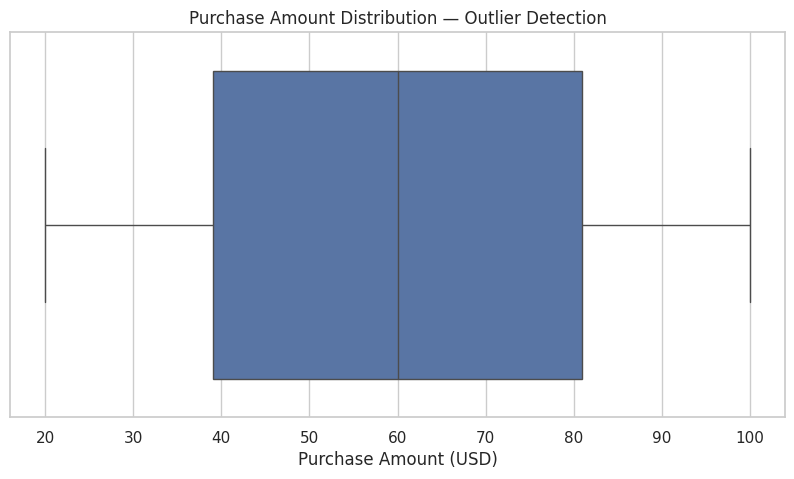

In [60]:
# First we will visualize it
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["purchase_amount"])

plt.title("Purchase Amount Distribution — Outlier Detection")
plt.xlabel("Purchase Amount (USD)")

plt.show()

We can also use the IQR method

In [61]:
Q1 = df["purchase_amount"].quantile(0.25)
Q3 = df["purchase_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -24.0
Upper Bound: 144.0


In [62]:
outliers = df[
    (df["purchase_amount"] < lower_bound) |
    (df["purchase_amount"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


Final Clean Dataset Check

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               3900 non-null   int64  
 1   age                       3900 non-null   int64  
 2   gender                    3900 non-null   object 
 3   item_purchased            3900 non-null   object 
 4   category                  3900 non-null   object 
 5   purchase_amount           3900 non-null   int64  
 6   location                  3900 non-null   object 
 7   size                      3900 non-null   object 
 8   color                     3900 non-null   object 
 9   season                    3900 non-null   object 
 10  review_rating             3900 non-null   float64
 11  subscription_status       3900 non-null   object 
 12  payment_method            3900 non-null   object 
 13  shipping_type             3900 non-null   object 
 14  discount

In [64]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 3900
Columns: 19
Missing values: 0
Duplicate rows: 0


In [65]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,payment_method,shipping_type,discount_applied,promo_code_used,previous_purchases,preferred_payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


## Exploratory Data Analysis

### 1. Customer Demographics

This section analyzes the demographic characteristics of customers,
including gender and age distribution, to understand the composition
of the customer base.

Gender Distribution

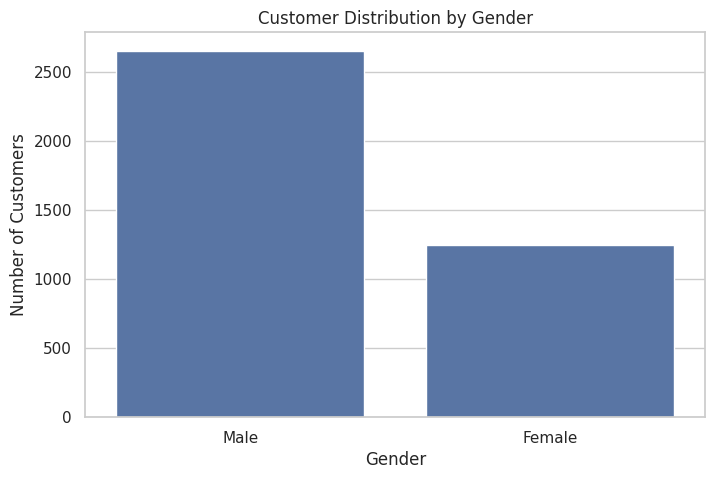

In [68]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

##Product Analysis

### 2. Product and Category Analysis

This section examines product popularity and purchasing behavior
across different product categories.

Most Purchased Items

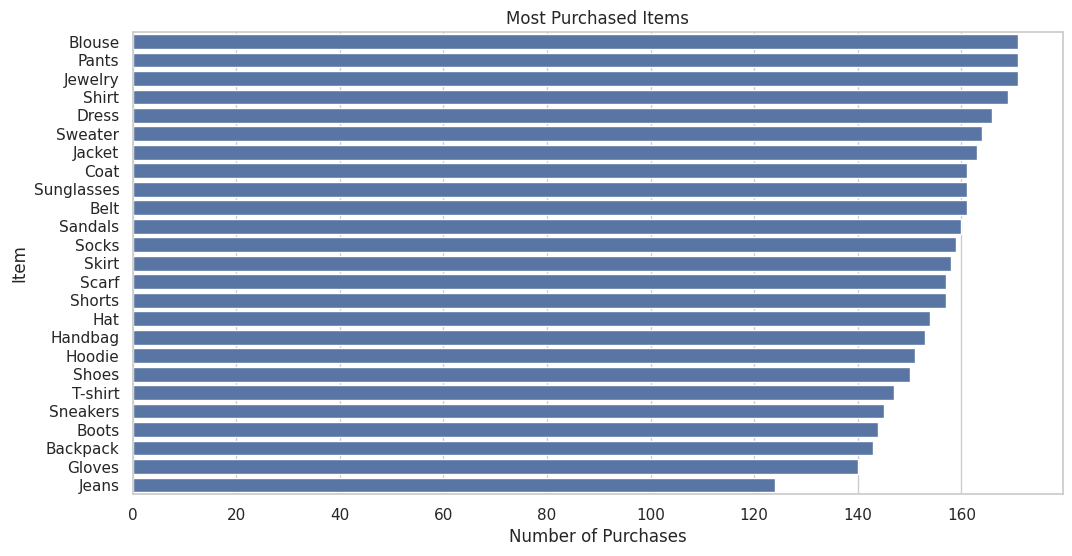

In [70]:
item_counts = df["item_purchased"].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=item_counts.values,
    y=item_counts.index
)

plt.title("Most Purchased Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Item")

plt.show()

In [71]:
item_counts.head(10)

,count
item_purchased,
Blouse,171
Pants,171
Jewelry,171
Shirt,169
Dress,166
Sweater,164
Jacket,163
Coat,161
Sunglasses,161


Purchases by Category

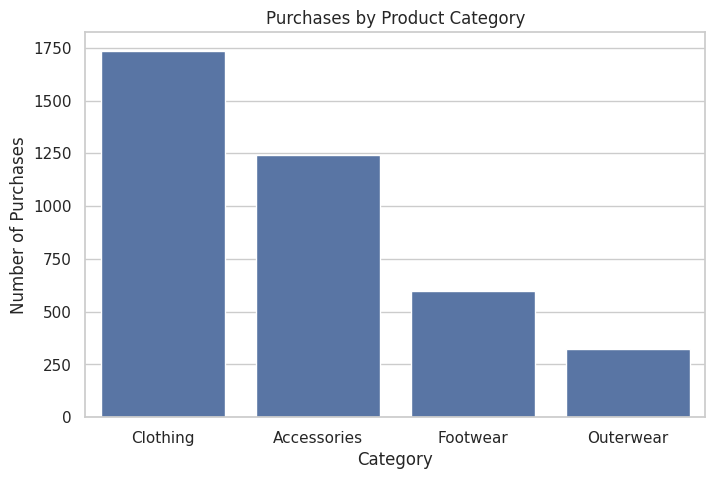

In [73]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Purchases by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.show()

Average Purchase Amount by Category

In [76]:
category_spending = (
    df.groupby("category")["purchase_amount"]
    .mean()
    .sort_values(ascending=False)
)

category_spending

,purchase_amount
category,
Footwear,60.255426
Clothing,60.025331
Accessories,59.838710
Outerwear,57.172840


Visualization

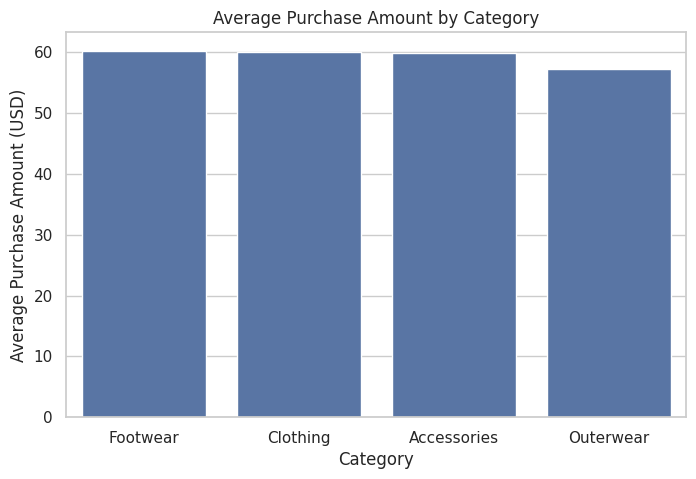

In [77]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_spending.index,
    y=category_spending.values
)

plt.title("Average Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()